# Prédiction de ventes -> à finir l'après midi.

L'objectif est de construire un modèle qui prédit les ventes sur la base de l'argent dépensé sur différentes plateformes telles que la télévision, la radio et les journaux pour le marketing.

In [1]:
#Import des libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Lecture de la database
df = pd.read_csv("advertising.csv")

0) Montrer les 10 premières lignes de df

In [3]:
df.head(10)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


## pré-traitement de données

In [4]:
df.shape

(200, 4)

**1. Vérification des valeurs manquantes**

In [5]:
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

**Conclusion:** La database ne contient pas de valeurs manquantes

**2. Vérification de la présence de lignes en double**

In [6]:
df.duplicated().any()

np.False_

**Conclusion:** Il n'y a pas de lignes dupliquées dans la database.

**3. Vérification des valeurs aberrantes**

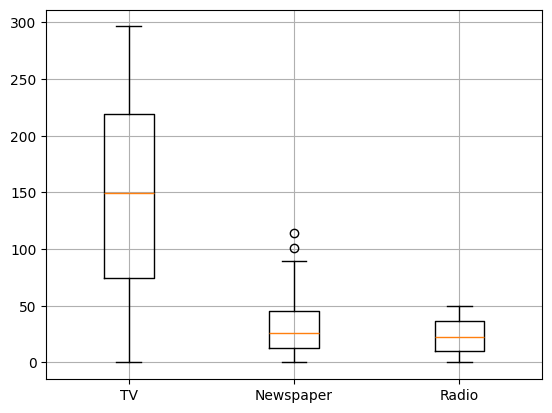

In [7]:
plt.boxplot([df['TV'],df['Newspaper'],df['Radio']], tick_labels = ['TV','Newspaper','Radio'])
plt.grid();
plt.show()

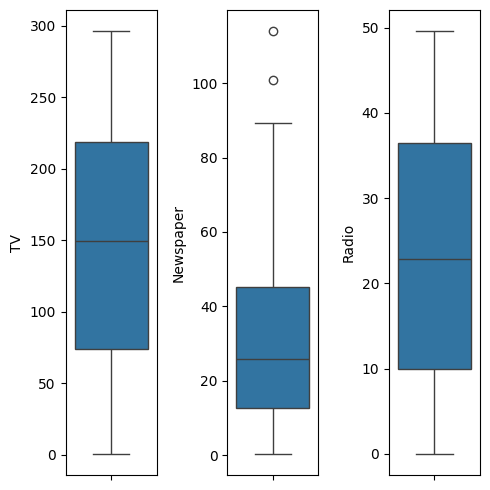

In [8]:
fig, axs = plt.subplots(1,3, figsize = (5,5))
plt1 = sns.boxplot(df['TV'], ax = axs[0])
plt2 = sns.boxplot(df['Newspaper'], ax = axs[1])
plt3 = sns.boxplot(df['Radio'], ax = axs[2])
plt.tight_layout()

**Remarque sur les valeurs aberrantes:** Il n'y a pas beaucoup de valeurs extrêmes dans la database.

## Analyse exploratoire des données

**4. Distribution de la variable cible**

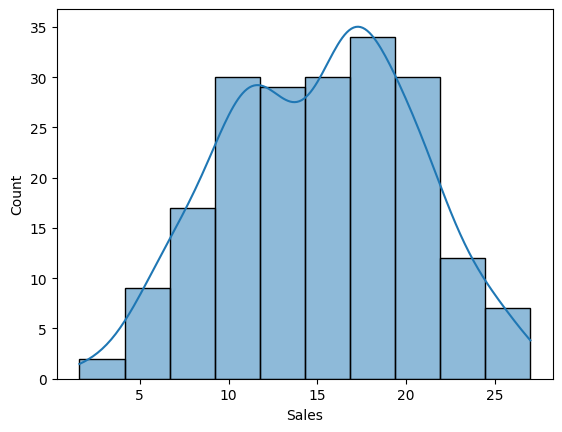

In [9]:
sns.histplot(df['Sales'], kde=True);

**Remarque sur la distribution des ventes:** distribution normale

**5. Comment les ventes sont-elles liées à d'autres variables ?**

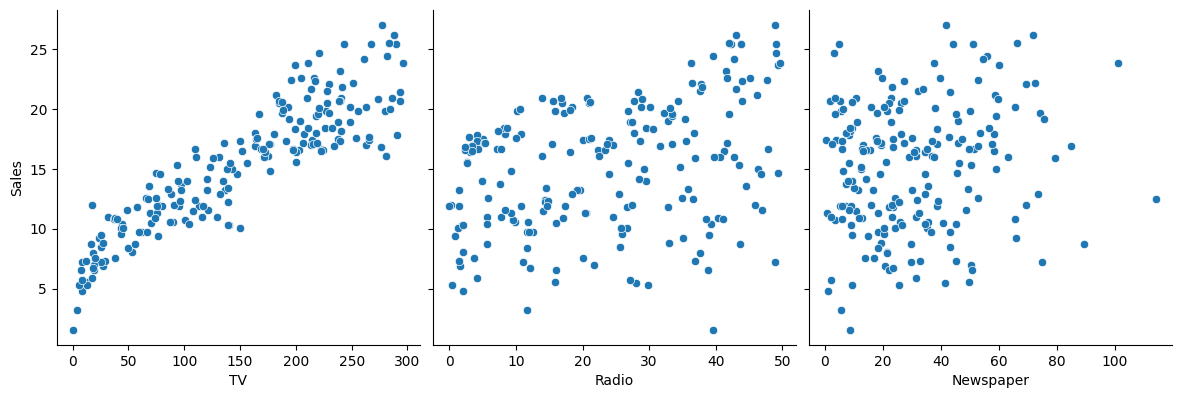

In [10]:
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.show()

**Votre remarque:** La télévision est fortement, positivement et linéairement corrélée avec la variable cible. Mais la caractéristique "Journal" ne semble pas corrélée.

**6. Heatmap**

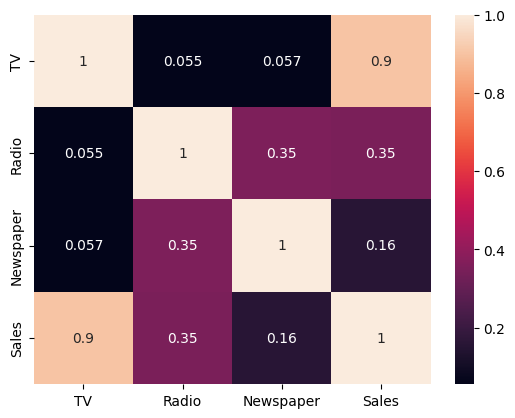

In [11]:
sns.heatmap(df.corr(), annot = True) # corrélation de Pearson (corrélation linéaire, à checker)
plt.show()

**Remarque:** La télévision semble être la plus corrélée avec les ventes, puisque 0,9 est très proche de 1.

## Construction de modèles

La régression linéaire est un outil utile pour prédire une réponse quantitative.

Prédiction à l'aide de :

    Régression linéaire simple 

    Régression linéaire multiple

### Régression linéaire simple

La régression linéaire simple ne comporte qu'une variable x et une variable y. Il s'agit d'une approche permettant de prédire une réponse quantitative à l'aide d'une seule caractéristique.

Elle établit la relation entre deux variables à l'aide d'une ligne droite. La régression linéaire tente de tracer une ligne qui se rapproche le plus des données en trouvant la pente et l'ordonnée à l'origine qui définissent la ligne et minimisent les erreurs de régression.

**Formule:** Y = β0 + β1X + e

    Y = Variable dépendante / Variable cible
    β0 = Ordonnée à l'origine de la droite de régression 
    β1 = Coefficient directeur
    X = Variable indépendante / Variable prédictive
    e = Erreur
    
**Equation:** Sales = β0 + β1X + TV

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [13]:
x = df[['TV']]
y = df['Sales']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 100)

In [15]:
slr= LinearRegression()  
slr.fit(x_train, y_train)

LinearRegression()

In [16]:
#coefficients de modèle
print('Intercept: ', slr.intercept_)
print('pente:', slr.coef_)

Intercept:  6.948683200001357
pente: [0.05454575]


In [17]:
print('Equation de Régression : Sales = {0}*TV + {1}'.format(round(slr.coef_[0],3),round(slr.intercept_,3)))

Equation de Régression : Sales = 0.055*TV + 6.949


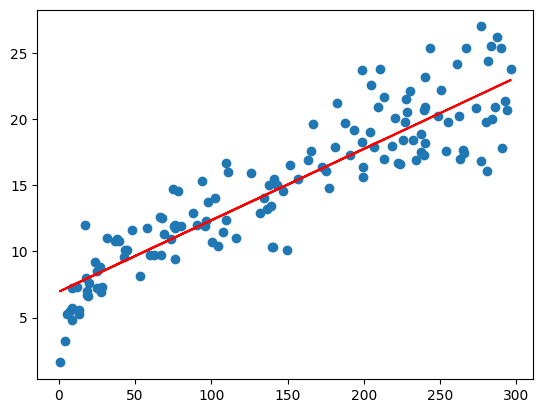

In [18]:
#Tracer la droite de régression
plt.scatter(x_train, y_train)
plt.plot(x_train, 6.948 + 0.054*x_train, 'r')
plt.show()

In [19]:
#Prédiction des résultats pour train et test 
y_pred_slr= slr.predict(x_test)  
x_pred_slr= slr.predict(x_train)  

In [20]:
#Valeur réelle et valeur prédite
slr_diff = pd.DataFrame({'Valeur réelle': y_test, 'valeur prédite': y_pred_slr})
slr_diff

,Valeur réelle,valeur prédite
126,6.6,7.374140
104,20.7,19.941482
99,17.2,14.323269
92,19.4,18.823294
111,21.8,20.132392
167,17.2,18.228745
116,12.2,14.541452
96,16.7,17.726924
52,22.6,18.752384
69,22.3,18.774202


In [21]:
# Afficher le score (coefficient de détermination R²)
from sklearn.metrics import accuracy_score
print('coefficient de détermination R² du modèle: {:.2f}'.format(slr.score(x,y)*100))

coefficient de détermination R² du modèle: 81.10


**Conclusion:** 81,10 % des données correspondent au modèle de régression

In [22]:
# 0 signifie que le modèle est parfait. La valeur doit donc être aussi proche de 0 que possible.
meanAbErr = metrics.mean_absolute_error(y_test, y_pred_slr)
meanSqErr = metrics.mean_squared_error(y_test, y_pred_slr)
rootMeanSqErr = np.sqrt(metrics.mean_squared_error(y_test, y_pred_slr))

print('Mean Absolute Error:', meanAbErr)
print('Mean Square Error:', meanSqErr)
print('Root Mean Square Error:', rootMeanSqErr)

Mean Absolute Error: 1.6480589869746525
Mean Square Error: 4.077556371826948
Root Mean Square Error: 2.019296008966231


### Régression linéaire multiple

La régression linéaire multiple comporte une variable y et deux variables x ou plus. Il s'agit d'une extension de la régression linéaire simple, car il faut plus d'une variable prédictive pour prédire la variable réponse.

La régression linéaire multiple est l'un des principaux algorithmes de régression qui modélise la relation linéaire entre une seule variable continue dépendante et plusieurs variables indépendantes.

Hypothèses pour la régression linéaire multiple :
    1. Une relation linéaire doit exister entre la cible et les variables prédictives.
    2. Les résidus de la régression doivent être normalement distribués.
    3. La MLR suppose que la multicolinéarité (corrélation entre les variables indépendantes) des données est faible ou inexistante.
    
**Formule:** Y = β0 + β1X1 + β2X2 + β3X3 + ... + βnXn + e

    Y = Variable dépendante / Variable cible
    β0 = Ordonnée à l'origine 
    β1, β2,..βn = coefficients directeur
    X1, X2,..Xn = Variables indépendantes / Variables prédictives
    e = Erreur
    
**Equation:** Sales = β0 + (β1 * TV) + (β2 * Radio) + (β3 * Newspaper)

**7. Définir x et y**

In [23]:
#Setting the value for X and Y
x = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

**8. Séparer en train et test**

In [24]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.3, random_state=100)  

**9. Entrainement du modèle de régression linéaire multiple**

In [25]:
mlr= LinearRegression()  
mlr.fit(x_train, y_train) 

LinearRegression()

**10. Afficher l'ordonnée à l'origine, les coefficients du modèle MLR et les noms des features correspondants**

In [26]:
#Printing the model coefficients
print('intercept = ', mlr.intercept_)
# pair the feature names with the coefficients
list(zip(x, mlr.coef_))

intercept =  4.334595861728431


[('TV', np.float64(0.053829108667250075)),
 ('Radio', np.float64(0.11001224388558056)),
 ('Newspaper', np.float64(0.006289950146130346))]

**11.Prédire les valeurs pour train et test**

In [27]:
#Predicting the Test and Train set result 
y_pred_mlr= mlr.predict(x_test)  
x_pred_mlr= mlr.predict(x_train)  

In [28]:
print("Prediction for test set: {}".format(y_pred_mlr))

Prediction for test set: [ 9.35221067 20.96344625 16.48851064 20.10971005 21.67148354 16.16054424
 13.5618056  15.39338129 20.81980757 21.00537077 12.29451311 20.70848608
  8.17367308 16.82471534 10.48954832  9.99530649 16.34698901 14.5758119
 17.23065133 12.56890735 18.55715915 12.12402775 20.43312609 17.78017811
 16.73623408 21.60387629 20.13532087 10.82559967 19.12782848 14.84537816
 13.13597397  9.07757918 12.07834143 16.62824427  8.41792841 14.0456697
  9.92050209 14.26101605 16.76262961 17.17185467 18.88797595 15.50165469
 15.78688377 16.86266686 13.03405813 10.47673934 10.6141644  20.85264977
 10.1517568   6.88471443 17.88702583 18.16013938 12.55907083 16.28189561
 18.98024679 11.33714913  5.91026916 10.06159509 17.62383031 13.19628335]


**12. Afficher le tableau des valeurs réelles et prédites pour test**

In [29]:
#Actual value and the predicted value
mlr_diff = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred_mlr})
mlr_diff

,Actual value,Predicted value
126,6.6,9.352211
104,20.7,20.963446
99,17.2,16.488511
92,19.4,20.109710
111,21.8,21.671484
167,17.2,16.160544
116,12.2,13.561806
96,16.7,15.393381
52,22.6,20.819808
69,22.3,21.005371


In [30]:
#Predict for any value
mlr.predict([[56, 55, 67]])

C:\Users\theodore\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.82112602])

**13. Afficher le coefficient R² pour la database**

In [31]:
# print the R-squared value for the model
print('Coefficient R² du modèle MLR: {:.2f}'.format(mlr.score(x,y)*100))

Coefficient R² du modèle MLR: 90.11


**Conclusion:** 90,11% des données correspondent au modèle de régression multiple, une amélioration d'environ 9% par rapport au modèle de régression simple.

**14. Afficher les erreurs MAE, MSE et RMSE**

In [32]:
# 0 means the model is perfect. Therefore the value should be as close to 0 as possible
meanAbErr = metrics.mean_absolute_error(y_test, y_pred_mlr)
meanSqErr = metrics.mean_squared_error(y_test, y_pred_mlr)
rootMeanSqErr = np.sqrt(metrics.mean_squared_error(y_test, y_pred_mlr))

print('Mean Absolute Error:', meanAbErr)
print('Mean Square Error:', meanSqErr)
print('Root Mean Square Error:', rootMeanSqErr)

Mean Absolute Error: 1.227818356658941
Mean Square Error: 2.6360765623280646
Root Mean Square Error: 1.6235998775338907


R Squared: R Square is the coefficient of determination. It tells us how many points fall on the regression line. The value of R Square is 90.11, which indicates that 90.11% of the data fit the regression model.

Mean Absolute Error: Mean Absolute Error is the absolute difference between the actual or true values and the predicted values. The lower the value, the better is the model’s performance. A mean absolute error of 0 means that your model is a perfect predictor of the outputs. The mean absolute error obtained for this particular model is 1.227, which is pretty good as it is close to 0.

Mean Square Error: Mean Square Error is calculated by taking the average of the square of the difference between the original and predicted values of the data. The lower the value, the better is the model’s performance. The mean square error obtained for this particular model is 2.636, which is pretty good.

Root Mean Square Error: Root Mean Square Error is the standard deviation of the errors which occur when a prediction is made on a dataset. This is the same as Mean Squared Error, but the root of the value is considered while determining the accuracy of the model. The lower the value, the better is the model’s performance. The root mean square error obtained for this particular model is 1.623, which is pretty good.